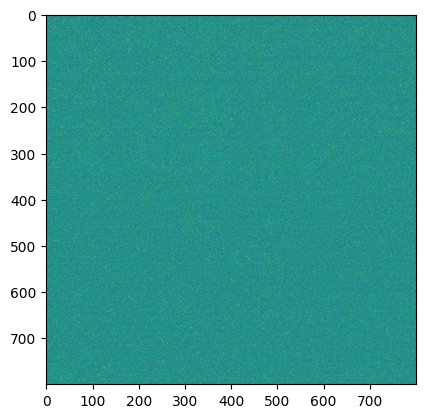

In [11]:
import numpy as np
import matplotlib.pyplot as plt
import config
import scipy

#100 dark shots, no scattering
bkgrnd_frames = np.load(f'{config.DATA_DIR}/bkgrnd.npy') #100x800x800
mean_bkgrnd = bkgrnd_frames.mean(axis=0)

frames_sub_mean = bkgrnd_frames - mean_bkgrnd

fig, ax = plt.subplots()
plt.imshow(frames_sub_mean[0], vmin=-20, vmax=20)


99

Text(0.5, 0, 'I - I$_{mean}$')

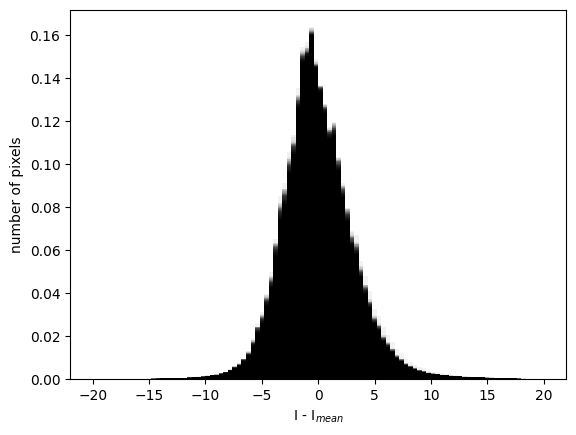

In [12]:
nbins= 100

vals = np.zeros((frames_sub_mean.shape[0], nbins))
for i, frame in enumerate(frames_sub_mean):
    print(i, end='\r')
    hist = plt.hist(frame.ravel(), bins = nbins, range = (-20,20),alpha=0.05,color=(0,0,0), density=True)
    vals[i] = hist[0]

bin_walls = hist[1]
bin_width = bin_walls[1]-bin_walls[1]
bin_mids = bin_walls[:-1]+bin_width/2

plt.ylabel("number of pixels")
plt.xlabel("I - I$_{mean}$")



5.062186139514493
1.3103571568836199


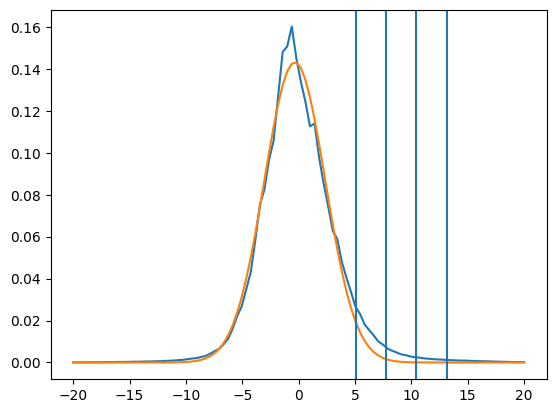

In [22]:
#plt.axvline(x=20+1/(np.e**2), ymin=0, ymax=4000)
plt.plot(bin_mids, vals.mean(axis=0))

bin_mids = np.linspace(-20,20, nbins)
def gauss(x, a, x0, sigma):
    return a * np.exp(-(x - x0)**2 / (2 * sigma**2))
popt, pcov = scipy.optimize.curve_fit(gauss, bin_mids, vals.mean(axis=0))
plt.plot(bin_mids, gauss(bin_mids, *popt))

#plt.axhline(popt[0]/(np.e**2))
plt.axvline(popt[1]+2*popt[2])
plt.axvline(popt[1]+3*popt[2])

plt.axvline(popt[1]+4*popt[2])
plt.axvline(popt[1]+5*popt[2])

print(popt[1]+2*popt[2])
print((popt[1]+2*popt[2])**(1/6))

5.062186139514493
1.3076604860118306
1.4677992676220695


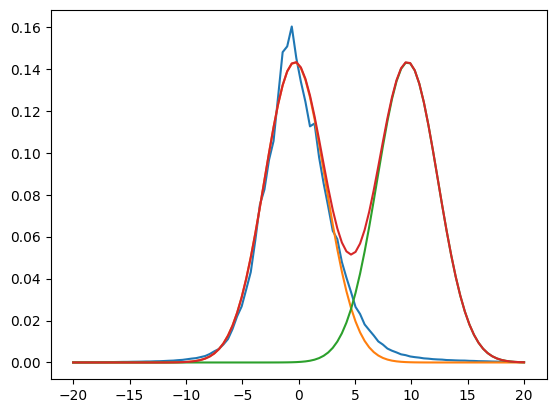

In [33]:
#plt.axvline(x=20+1/(np.e**2), ymin=0, ymax=4000)
plt.plot(bin_mids, vals.mean(axis=0))

bin_mids = np.linspace(-20,20, nbins)
def gauss(x, a, x0, sigma):
    return a * np.exp(-(x - x0)**2 / (2 * sigma**2))
popt, pcov = scipy.optimize.curve_fit(gauss, bin_mids, vals.mean(axis=0))
plt.plot(bin_mids, gauss(bin_mids, *popt))
plt.plot(bin_mids, gauss(bin_mids, a=popt[0], x0=popt[1]+10, sigma=popt[2]))

plt.plot(bin_mids, gauss(bin_mids, *popt)+gauss(bin_mids, a=popt[0], x0=popt[1]+10, sigma=popt[2]))



print(popt[1]+2*popt[2])
print((5)**(1/6))
print((10)**(1/6))